ResNet50

In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [3]:
import os
import tensorflow as tf


2026-05-09 15:57:12.791974: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 15:57:12.804292: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-09 15:57:12.817961: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-09 15:57:12.822114: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-09 15:57:12.831776: I tensorflow/core/platform/cpu_feature_guar

In [4]:
IMG_SIZE = 224

In [5]:
train_path = "../RAF_DB/DATASET/train"
test_path  = "../RAF_DB/DATASET/test"

In [6]:
def load_paths(dataset_path):
    paths, labels = [], []
    class_names = sorted(os.listdir(dataset_path))

    for label_idx, label in enumerate(class_names):
        label_path = os.path.join(dataset_path, label)

        for img_name in os.listdir(label_path):
            img_path = os.path.join(label_path, img_name)
            paths.append(img_path)
            labels.append(label_idx)

    return np.array(paths), np.array(labels), class_names

In [7]:
X1, y1, labels = load_paths(train_path)
X2, y2, _      = load_paths(test_path)



In [8]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X1,
    y1,
    test_size=0.15,
    stratify=y1,
    random_state=16
)

X_test= X2
y_test= y2

In [9]:
def parse_image(path, label, aumento=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    if aumento:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.2)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_saturation(img, 0.8, 1.2)
    img = tf.keras.applications.resnet.preprocess_input(img)
    return img, label


In [10]:
def build_dataset(paths, labels, batch_size=32, shuffle=True, aumento=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths))
    ds = ds.map(lambda x, y: parse_image(x, y, aumento=aumento), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [11]:
train_ds = build_dataset(X_train, y_train, aumento = True)
test_ds = build_dataset(X_test, y_test)
val_ds = build_dataset(X_val, y_val)

def contar_por_etiqueta(y, labels, nombre_split="Dataset"):
    unique, counts = np.unique(y, return_counts=True)
    print(f"\n{nombre_split}:")
    for label_idx, count in zip(unique, counts):
        print(f"{labels[label_idx]}: {count} muestras")

# Contar en cada split
contar_por_etiqueta(y_train, labels, "Train")
contar_por_etiqueta(y_test,  labels, "Test")
contar_por_etiqueta(y_val,  labels, "Val")


Train:
anger: 599 muestras
disgust: 609 muestras
fear: 239 muestras
happy: 4056 muestras
neutral: 2145 muestras
sad: 1685 muestras
surprise: 1097 muestras

Test:
anger: 162 muestras
disgust: 160 muestras
fear: 74 muestras
happy: 1185 muestras
neutral: 680 muestras
sad: 478 muestras
surprise: 329 muestras

Val:
anger: 106 muestras
disgust: 108 muestras
fear: 42 muestras
happy: 716 muestras
neutral: 379 muestras
sad: 297 muestras
surprise: 193 muestras


2026-05-09 15:57:16.226943: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5900 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:65:00.0, compute capability: 8.6


In [12]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: 2.4874791318864773, 1: 2.4466338259441707, 2: 6.2343096234309625, 3: 0.3673570019723866, 4: 0.6946386946386947, 5: 0.884272997032641, 6: 1.358249772105743}


In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras import layers, models

def build_model(lr, dense_units, dropout_rate):

    base_model = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False  # Fase 1: Entreno solo la cabeza

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)

    #Primera capa densa
    x = Dense(512, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    #Segunda capa densa
    x = Dense(dense_units, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate * 0.75)(x) ##Bajo un poco el dropout en la segunda capa 

    outputs = layers.Dense(len(labels), activation="softmax")(x)

    model_resnet = models.Model(inputs=inputs, outputs=outputs)
    model_resnet.summary()
    model_resnet.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model_resnet

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

callbacks = [
  tf.keras.callbacks.ModelCheckpoint( ##Se queda con el mejor modelo segun el val_loss
    filepath="convnet_from_scratch.keras",
    save_best_only=True,
    monitor="val_loss",
  ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",       # Monitorea val
        patience=5,               # Para si no mejora durante 5 epochs
        restore_best_weights=True # Recupera los mejores pesos al final
    ),
    tf.keras.callbacks.ReduceLROnPlateau( ##ajusta automaticamente el lr si el val_loss deja de mejorar
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7
    ),
]


### FASE 1

In [15]:
##Primero entrenamos solo la cabeza
model_resnet = build_model(
    lr=1e-3,
    dense_units=256,
    dropout_rate=0.3
)
history_fase1 = model_resnet.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks, class_weight=class_weights)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,772,999 (94.50 MB)

 Trainable params: 1,183,751 (4.52 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

...

325/326 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3493 - loss: 2.1455

2026-05-09 15:57:42.829972: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5633', 176 bytes spill stores, 176 bytes spill loads

2026-05-09 15:57:42.926880: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5633', 28 bytes spill stores, 28 bytes spill loads

2026-05-09 15:57:43.190408: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6470', 32 bytes spill stores, 32 bytes spill loads

2026-05-09 15:57:43.213453: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6470', 32 bytes spill stores, 32 bytes spill loads



326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3494 - loss: 2.1448

2026-05-09 15:57:52.486518: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1746', 176 bytes spill stores, 176 bytes spill loads

2026-05-09 15:57:52.581652: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1746', 12 bytes spill stores, 12 bytes spill loads



326/326 ━━━━━━━━━━━━━━━━━━━━ 38s 80ms/step - accuracy: 0.3941 - loss: 1.9277 - val_accuracy: 0.4047 - val_loss: 1.9314 - learning_rate: 0.0010
Epoch 2/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.4982 - loss: 1.5173 - val_accuracy: 0.5481 - val_loss: 1.3923 - learning_rate: 0.0010
Epoch 3/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.5379 - loss: 1.3675 - val_accuracy: 0.5454 - val_loss: 1.3764 - learning_rate: 0.0010
Epoch 4/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.5733 - loss: 1.2700 - val_accuracy: 0.5399 - val_loss: 1.3970 - learning_rate: 0.0010
Epoch 5/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.5985 - loss: 1.2010 - val_accuracy: 0.5872 - val_loss: 1.3321 - learning_rate: 0.0010
Epoch 6/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.6177 - loss: 1.1487 - val_accuracy: 0.5687 - val_loss: 1.3857 - learning_rate: 0.0010
Epoch 7/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.6362 - loss: 1.0914

In [16]:
mejorFase1 = tf.keras.models.load_model("convnet_from_scratch.keras")
mejorFase1.save("guardado_model_resnetFase1.keras")

In [ ]:
##De aqui pruebo a quitar el ReduceLROnPlateau y pruebo a ajustar lr con CosineDecayRestarts
callbacks_2 = [
  tf.keras.callbacks.ModelCheckpoint( ##Se queda con el mejor modelo 
    filepath="convnet_from_scratch.keras",
    save_best_only=True,
    monitor="val_loss",
  ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",       # Monitorea val
        patience=5,               # Para si no mejora durante 5 epochs
        restore_best_weights=True # Recupera los mejores pesos al final
    )
]

In [ ]:
##Luego entrenamos las ultimas capas
model_resnet = tf.keras.models.load_model("guardado_model_resnetFase1.keras")
base = model_resnet.get_layer("resnet50")
base.trainable = True
for layer in base.layers[:-50]: ##Pruebo a descongelar 50
    layer.trainable = False

lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=1e-5,
    first_decay_steps=500,
    t_mul=2.0,
    m_mul=0.9
)

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule), 
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_resnet.summary()

history_fase2 = model_resnet.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=callbacks_2, class_weight=class_weights)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,772,999 (94.50 MB)

 Trainable params: 18,134,279 (69.18 MB)

 Non-trainable params: 6,638,720 (25.32 MB)

Epoch 1/30


2026-05-09 16:01:19.633330: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_9282', 8 bytes spill stores, 8 bytes spill loads



325/326 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4874 - loss: 1.6055

2026-05-09 16:01:47.180388: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_9282', 12 bytes spill stores, 12 bytes spill loads

2026-05-09 16:01:47.223782: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_9282', 12 bytes spill stores, 12 bytes spill loads



326/326 ━━━━━━━━━━━━━━━━━━━━ 58s 111ms/step - accuracy: 0.5156 - loss: 1.4980 - val_accuracy: 0.5329 - val_loss: 1.5151
Epoch 2/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 22s 66ms/step - accuracy: 0.5861 - loss: 1.1446 - val_accuracy: 0.5524 - val_loss: 1.4370
Epoch 3/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 22s 66ms/step - accuracy: 0.6302 - loss: 0.9966 - val_accuracy: 0.5752 - val_loss: 1.3782
Epoch 4/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.6697 - loss: 0.8861 - val_accuracy: 0.5899 - val_loss: 1.3364
Epoch 5/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.6797 - loss: 0.8452 - val_accuracy: 0.6008 - val_loss: 1.3030
Epoch 6/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 22s 67ms/step - accuracy: 0.7011 - loss: 0.7919 - val_accuracy: 0.6209 - val_loss: 1.2542
Epoch 7/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 22s 66ms/step - accuracy: 0.7337 - loss: 0.7037 - val_accuracy: 0.6399 - val_loss: 1.2083
Epoch 8/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.7644 - loss: 0.6439 - val_accura

In [19]:
mejor_fase2 = tf.keras.models.load_model("convnet_from_scratch.keras")
mejor_fase2.save("guardado_model_resnetFase2.keras")
model_resnet = mejor_fase2

In [20]:
##METRICAS VARIAS
test_ds_ordered = build_dataset(X_test, y_test, shuffle= False)
y_pred = np.argmax(model_resnet.predict(test_ds_ordered), axis=1)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print("\nRecall por clase:")
print(classification_report(y_test, y_pred, target_names=labels))


95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

2026-05-09 16:12:13.827166: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1705', 176 bytes spill stores, 176 bytes spill loads

2026-05-09 16:12:13.891056: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1705', 28 bytes spill stores, 28 bytes spill loads



96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step

Accuracy: 0.7050195567144719
Balanced Accuracy: 0.6233225924311211
Macro F1: 0.6118112118857184

Recall por clase:
              precision    recall  f1-score   support

       anger       0.54      0.64      0.58       162
     disgust       0.32      0.38      0.35       160
        fear       0.50      0.47      0.49        74
       happy       0.89      0.79      0.84      1185
     neutral       0.65      0.68      0.66       680
         sad       0.65      0.69      0.67       478
    surprise       0.67      0.71      0.69       329

    accuracy                           0.71      3068
   macro avg       0.60      0.62      0.61      3068
weighted avg       0.72      0.71      0.71      3068



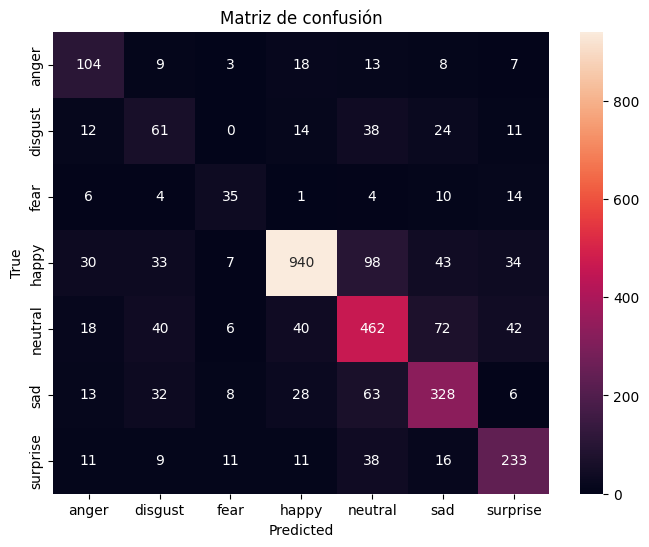

In [21]:
##MATRIZ DE CONFUSION

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Matriz de confusión")
plt.show()


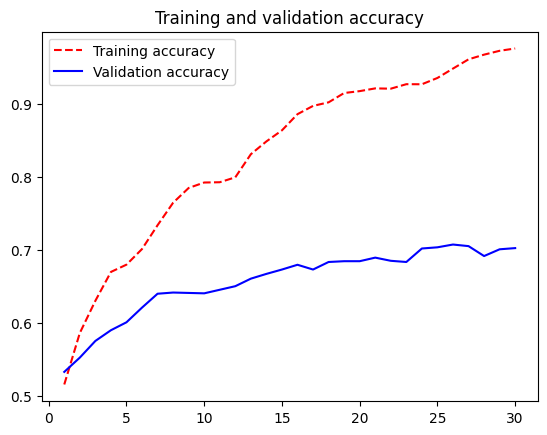

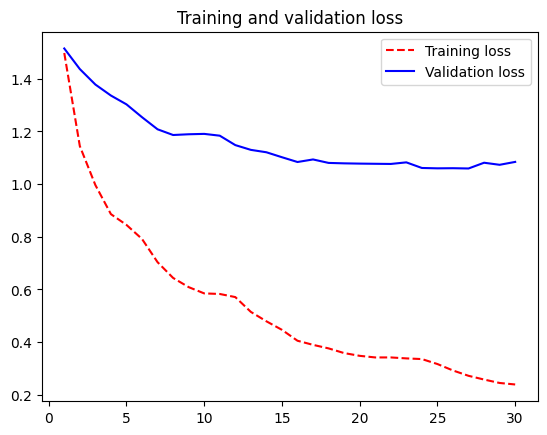

In [23]:
import matplotlib.pyplot as plt

accuracy = history_fase2.history["accuracy"]
val_accuracy = history_fase2.history["val_accuracy"]
loss = history_fase2.history["loss"]
val_loss = history_fase2.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [24]:
model_resnet.save("model_resnetTerminado.keras")